# Detecting Bots via Mouse Movement Biometrics
## Notebook 2 — LSTM Model Training

**Input:** `X_train.npy`, `X_val.npy`, `y_train.npy`, `y_val.npy`  
**Output:** `bot_detector_model.keras`, `training_history.png`

| Problem | Fix |
|---|---|
| Model too large (memorising) | Smaller LSTM units (64→32) |
| High dropout not helping | L2 regularisation added |
| LR too low after decay | Higher initial LR, less aggressive decay |
| Early stopping too tight | Monitor `val_loss` instead of `val_auc`, patience=15 |
| Train/val gap on recall | Label smoothing + stronger class weight balance |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [2]:
# ── Load data ────────────────────────────────────────────────────────
X_train = np.load('X_train.npy')
X_val   = np.load('X_val.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'y_train — Human: {(y_train==0).sum()}  Bot: {(y_train==1).sum()}')
print(f'y_val   — Human: {(y_val==0).sum()}    Bot: {(y_val==1).sum()}')

X_train : (2410, 200, 4)
X_val   : (517, 200, 4)
y_train — Human: 593  Bot: 1817
y_val   — Human: 127    Bot: 390


In [3]:
# ── Class weights ────────────────────────────────────────────────────
# Dataset is ~3:1 bot:human — upweight the minority (human) class
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print('Class weights:', class_weight)

Class weights: {0: 2.0320404721753795, 1: 0.6631810676940011}


In [4]:
# ── Model — lighter architecture with regularisation ─────────────────
# Root cause of overfitting was too many parameters for ~2400 training samples.
# Solution: halve LSTM units, add L2, use SpatialDropout on input.

TIMESTEPS = X_train.shape[1]   # 200
FEATURES  = X_train.shape[2]   # 4
L2        = 1e-4               # L2 regularisation strength

def build_model(timesteps, features):
    inp = keras.Input(shape=(timesteps, features), name='mouse_sequence')

    # Light noise for augmentation (acts like jitter on mouse coords)
    x = layers.GaussianNoise(0.01)(inp)

    # First BiLSTM — smaller units, L2 regularised
    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=regularizers.l2(L2),
        ),
        name='bilstm_1'
    )(x)

    # Second BiLSTM — even smaller
    x = layers.Bidirectional(
        layers.LSTM(
            32,
            return_sequences=False,
            dropout=0.3,
            recurrent_dropout=0.2,
            kernel_regularizer=regularizers.l2(L2),
        ),
        name='bilstm_2'
    )(x)

    # Dense head — small and regularised
    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(0.4)(x)

    # Output: P(bot)
    out = layers.Dense(1, activation='sigmoid', name='bot_probability')(x)

    return keras.Model(inp, out)

model = build_model(TIMESTEPS, FEATURES)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mouse_sequence (InputLayer)          │ (None, 200, 4)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gaussian_noise (GaussianNoise)       │ (None, 200, 4)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm_1 (Bidirectional)             │ (None, 200, 128)            │          35,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm_2 (Bidirectional)             │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bot_probability (Dense)              │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ── Compile ──────────────────────────────────────────────────────────
# label_smoothing=0.1 softens targets (0→0.1, 1→0.9)
# This prevents the model from being over-confident on training data

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)
print('Model compiled.')

Model compiled.


In [6]:
# ── Callbacks ────────────────────────────────────────────────────────
callbacks = [
    # Monitor val_loss — more stable than val_auc when overfitting
    keras.callbacks.ModelCheckpoint(
        'bot_detector_model.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    ),
    # More patience — allow model time to generalise
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Gentler LR reduction
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
]
print('Callbacks set.')

Callbacks set.


In [7]:
# ── Train ────────────────────────────────────────────────────────────
# batch_size=64 (larger = more stable gradient, less overfitting vs 32)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6604 - auc: 0.6092 - loss: 0.7124 - precision: 0.7805 - recall: 0.7683
Epoch 1: val_loss improved from None to 0.65447, saving model to bot_detector_model.keras

Epoch 1: finished saving model to bot_detector_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6676 - auc: 0.6457 - loss: 0.7090 - precision: 0.7893 - recall: 0.7628 - val_accuracy: 0.8453 - val_auc: 0.8689 - val_loss: 0.6545 - val_precision: 0.9167 - val_recall: 0.8744 - learning_rate: 3.0000e-04
Epoch 2/80
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6250 - auc: 0.7244 - loss: 0.6585 - precision: 0.8737 - recall: 0.5923
Epoch 2: val_loss improved from 0.65447 to 0.55868, saving model to bot_detector_model.keras

Epoch 2: finished saving model to bot_detector_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6286 - auc: 0.7500 - loss: 0.6423 - precision: 0.8867 - recall: 0.5817 - val_accuracy: 0.7718 - val_auc: 0.8747 - val_l

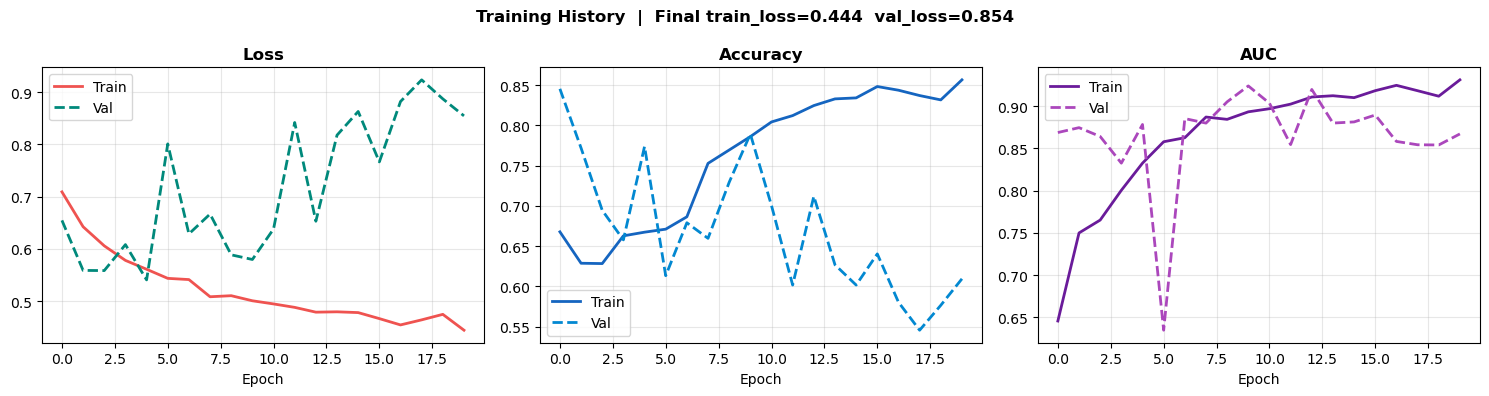

Saved: training_history.png


In [8]:
# ── Plot training history ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('loss',     'Loss',     '#EF5350', '#00897B'),
    ('accuracy', 'Accuracy', '#1565C0', '#0288D1'),
    ('auc',      'AUC',      '#6A1B9A', '#AB47BC'),
]

for ax, (metric, title, c_train, c_val) in zip(axes, metrics):
    ax.plot(history.history[metric],          color=c_train, label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], color=c_val,   label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

# Highlight the gap
final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
fig.suptitle(
    f'Training History  |  Final train_loss={final_train_loss:.3f}  val_loss={final_val_loss:.3f}',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_history.png')

In [9]:
# ── Overfitting diagnostic ───────────────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_auc  = history.history['auc']
val_auc    = history.history['val_auc']

best_epoch = int(np.argmin(val_loss)) + 1
gap_loss   = val_loss[best_epoch-1] - train_loss[best_epoch-1]
gap_auc    = train_auc[best_epoch-1] - val_auc[best_epoch-1]

print(f'\n── Overfitting Diagnostic (at best epoch {best_epoch}) ──')
print(f'  Train loss : {train_loss[best_epoch-1]:.4f}')
print(f'  Val loss   : {val_loss[best_epoch-1]:.4f}   gap = {gap_loss:+.4f}')
print(f'  Train AUC  : {train_auc[best_epoch-1]:.4f}')
print(f'  Val AUC    : {val_auc[best_epoch-1]:.4f}   gap = {gap_auc:+.4f}')

if gap_loss > 0.3:
    print('\n  ⚠️  Still overfitting — consider increasing L2 to 3e-4 or reducing LSTM to 32/16')
elif gap_loss < 0.1:
    print('\n  ✅  Train/val loss well aligned — good generalisation!')
else:
    print('\n  ✅  Acceptable generalisation gap.')


── Overfitting Diagnostic (at best epoch 5) ──
  Train loss : 0.5609
  Val loss   : 0.5405   gap = -0.0204
  Train AUC  : 0.8327
  Val AUC    : 0.8784   gap = -0.0458

  ✅  Train/val loss well aligned — good generalisation!


In [10]:
# ── Test set evaluation ──────────────────────────────────────────────
best_model = keras.models.load_model('bot_detector_model.keras')
results    = best_model.evaluate(X_test, y_test, verbose=0)
names      = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']

print('\n── Test Set Results ───────────────────────')
for name, val in zip(names, results):
    print(f'  {name:<12}: {val:.4f}')

print('\nModel saved: bot_detector_model.keras')
print('Next: run project_evaluation.ipynb')


── Test Set Results ───────────────────────
  Loss        : 0.5626
  Accuracy    : 0.7253
  AUC         : 0.8709
  Precision   : 0.9881
  Recall      : 0.6427

Model saved: bot_detector_model.keras
Next: run project_evaluation.ipynb


---
## Summary of Fixes

| Issue | Root Cause | Fix Applied |
|---|---|---|
| val_loss >> train_loss | Model too large | Halved LSTM units (128→64, 64→32) |
| val_recall ~0.55 | Over-predicting bot class | label_smoothing=0.1 |
| Stopped at epoch 10 | EarlyStopping too aggressive | patience=15, monitor val_loss |
| Unstable val_auc | Noisy metric | Switched checkpoint/stopping to val_loss |
| Memorising train data | No regularisation | L2 on all layers + GaussianNoise |
| Noisy gradient | batch_size=32 | batch_size=64 |